Taavon Peoples QML Project

Data Encoding


weights are the output of training (fine tuning starts with weights from training)
-----

Try to reorder the features  to prove it works once we get a good result

We need to look at the data set again. There is not a line to be drawn for this use case. Maybe try looking at the original python script for tips. 

In [1]:
# If you have not already, install scikit learn
%pip install scikit-learn
%pip install qiskit
%pip install qiskit-aer --quiet
%pip install pylatexenc
%pip install matplotlib
%pip install qiskit-ibm-runtime
%pip install qiskit-ibm-transpiler

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\tjpee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import sys
from pathlib import Path
import importlib

# add project root (current working dir or nearest parent containing utils.py) to sys.path and import utils
cwd = Path.cwd().resolve()
for folder in [cwd] + list(cwd.parents):
    if (folder / "utils.py").is_file():
        sys.path.insert(0, str(folder))
        utils = importlib.import_module("utils")
        break
else:
    raise FileNotFoundError("utils.py not found in project root or any parent directory")

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService


QiskitRuntimeService.save_account(
     token="yZoR4zRA8X7ZX2rauN_pkmyBrId1CJbbXR1RoN_dFvJh", #personal
     set_as_default = True
     )

QiskitRuntimeService.save_account(
     name="school",
     token="le-oO5tzHgBtECyLLKsPwvua8PGGWlshIAXyBxhN0BwS" #school
     )

In [ ]:
QiskitRuntimeService.saved_accounts()
testing = QiskitRuntimeService(name="school")

BEGIN METHODs needed for QNN 

In [5]:
def encode_grade(grade):
    if grade == 'A':
        return 1
    elif grade == 'B':
        return 2
    elif grade == 'C':
        return 3
    elif grade == 'D':
        return 4
    elif grade == 'F':
        return 5
    else:
        return 0
    
def convert_to_label(grade):
    if grade in ['A', 'B']:
    #if grade in ['A']:
        return 1
    else:
        return -1

In [6]:
from math import pi
import pandas as pd
import numpy as np

def process_dataset(dataset: pd.DataFrame, samples: int, random_seed: int) -> np.array:
    subset = dataset.sample(n=samples, random_state=random_seed)
    array_stacked = np.column_stack([subset[col].values for col in ['Grade', 'White','Black', 'Hispanic', 'Asian', 'Other', 'Total', 'NO2', 'PHOLC', 'PM25']])
    processed_data = list()

    # Normalize the data by dividing each value by the total number of samples in that row (column 6)
    # Normalize the totals by dividing by the max total in the dataset
    max = np.max(array_stacked[:, 6])
    for row in array_stacked:
        processed_data.append(np.array([
                            #(row[1] / row[6]) * 2 * pi, # % of White population
                            #(row[2] / row[6]) * 2 * pi, # % of Black population
                            #(row[3] / row[6]) * 2 * pi, # % of Hispanic population
                            #(row[4] / row[6]) * 2 * pi, # % of Asian population
                            #(row[5] / row[6]) * 2 * pi, # % of Other population
                            (row[6] / max ) * 2 * pi,     # Normalized total
                            row[7],           # NO2 levels | Low is good
                            row[8],           # PHOLC levels
                            row[9],          # PM25 levels | high is bad
                            convert_to_label(row[0])]))  # Grade is encoded as a label, where A and B are 1 (good) and C, D, F are -1 (bad)          
    return np.array(processed_data)

In [7]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import z_feature_map, zz_feature_map
from qiskit.circuit.library import unitary_overlap

def create_encoding_circuits(dataset: pd.DataFrame, useZZ: bool) -> tuple [int, QuantumCircuit, QuantumCircuit]: 
    # Data points with labels removed, for inner product    
    train_data=[dataset[0][:-1], dataset[1][:-1]]

    # Encode the data into quantum states using the ZFeatureMap    
    if(useZZ):
        fm = zz_feature_map(feature_dimension=np.shape(train_data)[1], entanglement='linear', reps=1)
    else :
        fm = z_feature_map(feature_dimension=np.shape(train_data)[1])

    num_qubits = fm.num_qubits

    #Assign Params
    unitary1 = fm.assign_parameters(train_data[0])
    unitary2 = fm.assign_parameters(train_data[1])

    overlap_circ = unitary_overlap(unitary1, unitary2)
    overlap_circ.measure_all()
    return num_qubits, fm, overlap_circ

In [8]:
# Import the necessary packages
import array

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


''' For full dataset
  0 - # % of White population
  1 - # % of Black population
  2 - # % of Hispanic population
  3 - # % of Asian population
  4 - # % of Other population
  5 - # Normalized total 
  6 - # NO2 levels | Low is good
  7 - # PHOLC levels 
  8 - # PM25 levels | high is bad
'''
def create_ansatz_circuit(qubits: int, superposition: bool, gate_list: array) -> QuantumCircuit:
    # Initialize the circuit using the same number of qubits as the image has pixels
    qnn_circuit = QuantumCircuit(qubits)

    # We choose to have two variational parameters for each qubit.
    params = ParameterVector("θ", length=2 * qubits)   

    # A first variational layer:
    for i in range(qubits):
        qnn_circuit.ry(params[i], i)
        if superposition:
            qnn_circuit.h(i)

    

    # Ansatz Designs will go here 
    # These should include ALL QUBITS
    # Here is a list of qubit pairs between which we want CNOT gates. 
    # Change this to include ALL of the demographic group qubits    
    for i in range(len(gate_list)):
        match len(gate_list[i]):
            case 1: # Create a X gate
                qnn_circuit.x(gate_list[i][0])
            case 2: 
                qnn_circuit.cx(gate_list[i][0], gate_list[i][1])
            case 3:
                qnn_circuit.ccx(gate_list[i][0], gate_list[i][1], gate_list[i][2])

    # The second variational layer:
    for i in range(qubits):
        qnn_circuit.rx(params[qubits + i], i)

    return qnn_circuit

In [9]:
import matplotlib.pyplot as plt

# Try pass manager several times, since heuristics can return various transpilations on large circuits, and we want the shallowest.
def find_min_transpiled_circuit(circuit: QuantumCircuit) -> QuantumCircuit:
    global pm
    transpiled_qcs = []
    transpiled_depths = []
    transpiled_2q_depths = []
    for i in range(1, 10):
        circuit_ibm = pm.run(circuit)
        transpiled_qcs.append(circuit_ibm)
        transpiled_depths.append(circuit_ibm.decompose().depth())
        transpiled_2q_depths.append(
            circuit_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)
        )
    # print(i)
    minpos = transpiled_2q_depths.index(min(transpiled_2q_depths))
    print(transpiled_depths)
    print(transpiled_2q_depths)

    # Use the shallowest
    return transpiled_qcs[minpos]

def visualize_counts(probs, num_qubits):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True)[:10])
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]
    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Counts")
    plt.show()

In [10]:
import copy
from qiskit.primitives import BaseEstimatorV2
from qiskit.quantum_info.operators.base_operator import BaseOperator

def forward(
    circuit: QuantumCircuit,
    input_params: np.ndarray,
    weight_params: np.ndarray,
    estimator: BaseEstimatorV2,
    observable: BaseOperator,
) -> np.ndarray:
    """
    Forward pass of the neural network.

    Args:
        circuit: circuit consisting of data loader gates and the neural network ansatz.
        input_params: data encoding parameters.
        weight_params: neural network ansatz parameters.
        estimator: EstimatorV2 primitive.
        observable: a single observable to compute the expectation over.

    Returns:
        expectation_values: an array (for one observable) or a matrix (for a sequence of observables) of expectation values.
        Rows correspond to observables and columns to data samples.
    """
    num_samples = input_params.shape[0]
    weights = np.broadcast_to(weight_params, (num_samples, len(weight_params)))
    params = np.concatenate((input_params, weights), axis=1)
    pub = (circuit, observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    expectation_values = result.data.evs

    return expectation_values

def mse_loss(predict: np.ndarray, target: np.ndarray) -> np.ndarray:
    """
    Mean squared error (MSE).

    prediction: predictions from the forward pass of neural network.
    target: true labels.

    output: MSE loss.
    """
    if len(predict.shape) <= 1:
        return ((predict - target) ** 2).mean()
    else:
        raise AssertionError("input should be 1d-array")
    

def mse_loss_weights(weight_params: np.ndarray) -> np.ndarray:
    global objective_func_vals, circuit, input_params, estimator, observable
    """
    Cost function for the optimizer to update the ansatz parameters.

    weight_params: ansatz parameters to be updated by the optimizer.

    output: MSE loss.
    """
    predictions = forward(
        circuit=circuit,
        input_params=input_params,
        weight_params=weight_params,
        estimator=estimator,
        observable=observable,
    )

    cost = mse_loss(predict=predictions, target=target)
    objective_func_vals.append(cost)

    global iter
    if iter % 50 == 0:
        print(f"Iter: {iter}, loss: {cost}")
    iter += 1

    return cost

def convert_prediction_to_label(pred_test: np.ndarray) -> np.ndarray:
    pred_test_labels = copy.deepcopy(pred_test)
    pred_test_labels[pred_test_labels >= 0] = 1
    pred_test_labels[pred_test_labels < 0] = -1
    return pred_test_labels

END METHODs needed for QNN

Step 1 Data Encoding
Map inputs to quantum circuit


For 3 qubits

Larger batch size helps. Moving to 300 with 5 epocs

6/2/26
3 qubits (columns 7-9)
Ansatz | qnn_cnot_list = [[0,1],[1,2],[2,0]]
5000 samples, 1 epoch
Train accuracy: 61.7%

10000 samples, 5 epochs
Final Weights: [68.8650189   6.57187514  2.92450382  4.60754767  0.2340288   1.57319311]
Train accuracy: 60.6%

Results Stored in XLS

Ansatz > 60%
Ansatz 1 | qnn_cnot_list = [[0,2,1], [1,2], [2,0], [0,1], [0,1,2]]
Ansatz 2 | qnn_cnot_list = [[0], [0,1,2], [2,1], [1,0]]
Ansatz 3 | qnn_cnot_list = [[0,1], [1,2], [2,1,0], [0,1,2]]
Ansatz 4 | qnn_cnot_list = [[0,1],[1,2],[2,0]]
Ansatz 5 | qnn_cnot_list = [[0,2,1], [1,2], [2,0], [0,1]]
Ansatz 6 | qnn_cnot_list = [[1,2], [2,0],[0,1]] 
Ansatz 7 | qnn_cnot_list = [[0,2,1], [1,2], [2,1,0], [0,1], [1,2]]
Ansatz 7 | qnn_cnot_list = [[0,2,1], [1,2], [2,1,0], [0,1], [1,2]]
Ansatz 8 | qnn_cnot_list = [[0,2,1], [1,2], [2,1,0],[0, 1],[0,1,2]]
Ansatz 9 | qnn_cnot_list = [[1,0], [2], [0,2,1], [1,2], [2,0],[0, 1],[0,1,2]] | with H gates


Ansatz < 60% (Bad candidates)
Ansatz | qnn_cnot_list = [[0], [2,1], [0,2], [1,0]] | 56%
Ansatz | qnn_cnot_list = [[1,2], [0,1], [2,1,0]] | 57%
Ansatz | qnn_cnot_list = [[0,1,2], [0,1], [2,1,0]] | 59


4 Qubits
----
Ansatz 1 |qnn_cnot_list = [[0,1,2], [1,2, 3], [0,3,1], [3,2,0]] #Ansatz 


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from utils import init

# This only needs to be run once, as the dataset is cached after the first run
dataset = init()

# Baltimore statistics
baltimore_dataset = dataset[dataset['City'] == 'Baltimore, MD']

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from math import pi

sample_size = 10000
train_size = int(.8 * sample_size)
test_size = int(.2 * sample_size)

processed_data = process_dataset(dataset=baltimore_dataset, samples=sample_size, random_seed=42)                                      

print(processed_data) 

# Create the data sets from the processed data
# Training with more data
X_train = processed_data[0:train_size, :-1]
# The last column of the dataset contains the labels, so we take that for training labels
train_labels = processed_data[0:train_size, -1]

# Prepare testing data
X_test = processed_data[train_size : train_size + test_size, :-1]
test_labels = processed_data[train_size : train_size + test_size, -1]

num_samples = np.shape(X_train)[0]

[[ 2.07015010e-01  1.04298000e+01  1.00000000e+00  1.16495000e+01
  -1.00000000e+00]
 [ 1.49200007e-02  1.53623000e+01  9.87586113e-01  1.14141000e+01
  -1.00000000e+00]
 [ 2.16340011e-01  1.40830000e+01  1.00000000e+00  1.02635000e+01
   1.00000000e+00]
 ...
 [ 1.21225006e-01  9.52658000e+00  1.00000000e+00  1.13026000e+01
   1.00000000e+00]
 [ 1.93960009e-01  8.81593000e+00  1.00000000e+00  1.02450000e+01
   1.00000000e+00]
 [ 2.70425013e-01  1.21029000e+01  1.00000000e+00  1.19025000e+01
  -1.00000000e+00]]


circuit depth =  23


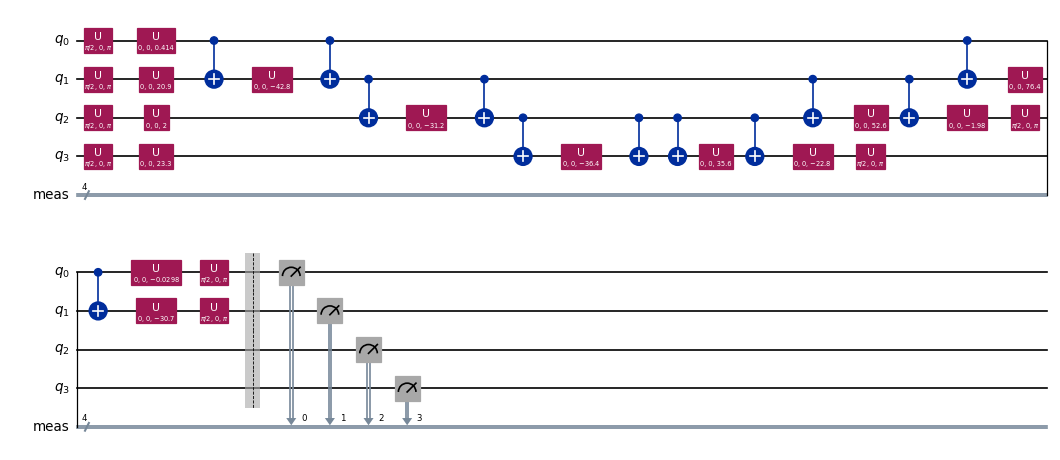

In [13]:
# Execute Data Encoding 
num_qubits, fm, overlap_circ = create_encoding_circuits(processed_data, True)
print("circuit depth = ", overlap_circ.decompose().depth())
overlap_circ.decompose().draw("mpl", scale=0.6, style="iqp")

Create Ansatz to show data relationships. 

Think about how the values are related

46
2+ qubit depth: 24


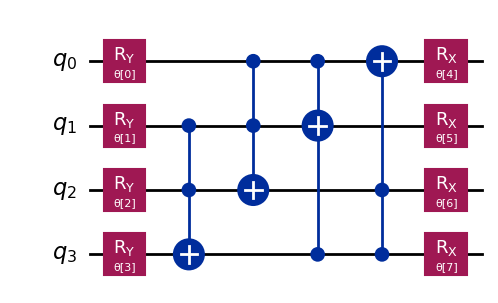

In [45]:
# Import the necessary packages
from qiskit import QuantumCircuit

# Here is a list of qubit pairs between which we want CNOT gates. The choice of these is not yet obvious.
# Change this to include ALL of the demographic group qubits 

#qnn_cnot_list = [[0], [0,1,2], [2,1],[1,0]] # Ansatz 2
#qnn_cnot_list =  [ [0,2,1],[1,2], [2,0],[0, 1],[0,1,2] ] #Ansatz 1
#qnn_cnot_list = [ [0,1], [1,2], [2,1,0], [0,1,2]] #Ansatz 3
#qnn_cnot_list = [[1,0], [0,2,1], [1,2], [2,0],[0, 1],[0,1,2]] #Ansatz 
qnn_cnot_list = [ [1,2, 3],[0,1,2],[0,3,1], [3,2,0]] #Ansatz 

ansatz = create_ansatz_circuit(qubits=num_qubits, superposition=False, gate_list=qnn_cnot_list)
# Check the circuit depth, and the two-qubit gate depth
print(ansatz.decompose().depth())
print(
    f"2+ qubit depth: {ansatz.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

# Draw the circuit
ansatz.draw("mpl")

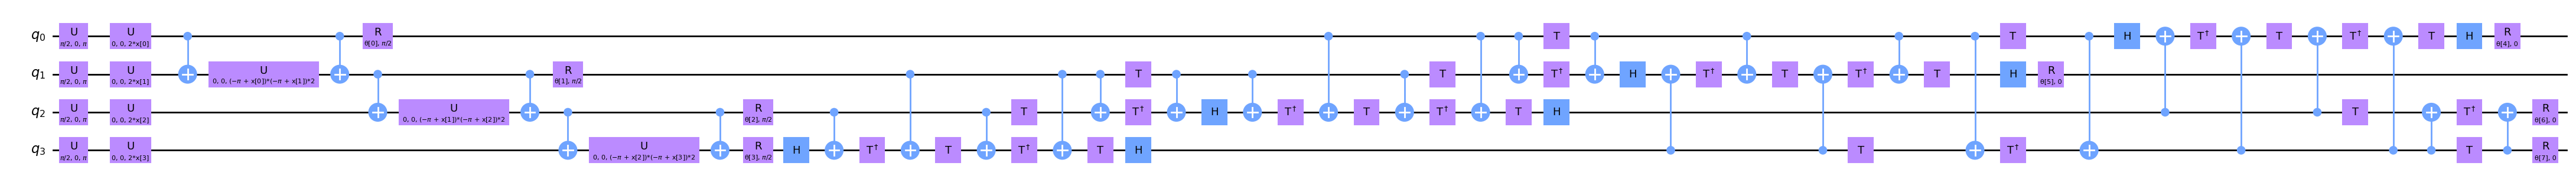

In [46]:
# QNN ansatz


# Combine the feature map with the ansatz
full_circuit = QuantumCircuit(num_qubits)
full_circuit.compose(fm, range(num_qubits), inplace=True)
full_circuit.compose(ansatz, range(num_qubits), inplace=True)

# Display the circuit
full_circuit.decompose().draw("mpl", style="clifford", fold=-1)

Step 2
Optimize the circuit for execution

In [17]:
# Import needed packages
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

# Get the least busy backend


service = QiskitRuntimeService()
# Using secondary QRS
#service = QiskitRuntimeService(name="school")
backend = service.least_busy(
    # NOTE: Using Simulator for testing, for speed
    operational=True, simulator=False, min_num_qubits=num_qubits
)
print(backend)

qiskit_runtime_service.__init__:WARNING:2026-07-01 11:27:30,367: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (pay-as-you-go, open), the available account instances are: open-instance, paid-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-01 11:27:30,935: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-01 11:27:31,461: Loading instance: paid-instance, plan: pay-as-you-go
qiskit_runtime_service.backends:WARNING:2026-07-01 11:27:33,759: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


Transpilation STEPS (Compiling gates into native gates)

In [18]:
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import (
    ALAPScheduleAnalysis,
    ConstrainedReschedule,
    PadDynamicalDecoupling,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target_backend = backend.target

pm = generate_preset_pass_manager(target=target_backend, optimization_level=3)
pm.scheduling = PassManager(
    [
        ALAPScheduleAnalysis(target=target_backend),
        ConstrainedReschedule(
            acquire_alignment=target_backend.acquire_alignment,
            pulse_alignment=target_backend.pulse_alignment,
            target=target_backend,
        ),
        PadDynamicalDecoupling(
            target=target_backend,
            dd_sequence=[XGate(), XGate()],
            pulse_alignment=target_backend.pulse_alignment,
        ),
    ]
)

In [33]:
from qiskit.quantum_info import SparsePauliOp

circuit_ibm = find_min_transpiled_circuit(circuit=full_circuit)

observable = SparsePauliOp.from_list([("Z" * (num_qubits), 1)])
observable_ibm = observable.apply_layout(circuit_ibm.layout)

print(circuit_ibm.decompose().depth())
print(
    f"2+ qubit depth: {circuit_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)}"
)

overlap_ibm = pm.run(overlap_circ)

[371, 366, 366, 372, 372, 367, 367, 366, 366]
[44, 44, 44, 46, 46, 46, 46, 44, 44]
371
2+ qubit depth: 44


Add a section to draw the circuit after transpilation

In [ ]:
# Display the transpiled circuit
circuit_ibm.decompose().draw("mpl", style="clifford", fold=-1)

Step 3: Execute the circuit

SIMULATOR 

In [20]:
# Run this for a simulator
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Options, Session, Sampler

#num_shots = 1000
num_shots = sample_size

# Evaluate the problem using state vector-based primitives from Qiskit
sampler = StatevectorSampler()
results = sampler.run([overlap_circ], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

In [38]:
from scipy.optimize import minimize
from qiskit.primitives import StatevectorEstimator as Estimator

def execute_training_with_estimator(batch_size: int, epochs: int, samples: int, qc: QuantumCircuit, weight_params: np.ndarray): 
    global estimator, objective_func_vals, target, iter, input_params, circuit, X_train, train_labels
    estimator = Estimator()
    circuit = qc

    objective_func_vals = []
    iter = 0


    if weight_params is None:
        # Random initial weights for the ansatz
        np.random.seed(42)

        # This should not be random, changes this
        weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi  
    '''
        # % of White population
        # % of Black population
        # % of Hispanic population
        # % of Asian population
        # % of Other population
        # Normalized total 
        # NO2 levels | Low is good
        # PHOLC levels
        # PM25 levels | high is bad
    '''
    for epoch in range(epochs):
        for i in range((samples - 1) // batch_size + 1):
            print(f"Epoch: {epoch}, batch: {i}")
            print(weight_params)
            start_i = i * batch_size
            end_i = start_i + batch_size
            train_data_batch = np.array(X_train[start_i:end_i])
            train_labels_batch = np.array(train_labels[start_i:end_i])
            input_params = train_data_batch
            target = train_labels_batch
            iter = 0
            res = minimize(
                # Look into changing this method
            mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
            )
            weight_params = res["x"]

    return weight_params

In [42]:
'''
SIMULATOR
'''
weight_params = execute_training_with_estimator(batch_size=800, epochs=10, samples=len(X_train), qc=full_circuit, weight_params=[0.07975498, 9.26084108, 8.3023754, 2.26392614, 2.48614076,  3.22543777, 0.78933578, 6.47991025])




Epoch: 0, batch: 0
[0.07975498, 9.26084108, 8.3023754, 2.26392614, 2.48614076, 3.22543777, 0.78933578, 6.47991025]
Iter: 0, loss: 0.8964376491220422
Iter: 50, loss: 0.8873117188465593
Epoch: 0, batch: 1
[0.41336358 9.11248752 8.21830495 2.24004877 2.29836028 3.27864961
 1.04243111 6.45138578]
Iter: 0, loss: 0.8990974184628044
Iter: 50, loss: 0.8920859821583056
Epoch: 0, batch: 2
[0.25306974 9.5134275  8.27553524 2.25734681 2.45178677 3.35484279
 1.03414787 6.42981306]
Iter: 0, loss: 0.9232690809975378
Iter: 50, loss: 0.9179738888814226
Epoch: 0, batch: 3
[0.32205755 9.39265061 8.24702334 2.1646808  2.39484331 3.20924311
 0.77334772 6.67112978]
Iter: 0, loss: 0.9041073679684948
Iter: 50, loss: 0.8905381916764006
Epoch: 0, batch: 4
[0.43276257 9.32276988 8.18827001 2.28527886 2.4707813  3.3619772
 0.95138957 6.36400381]
Iter: 0, loss: 0.8939823401038797
Iter: 50, loss: 0.8847300908272221
Epoch: 0, batch: 5
[0.26885819 9.20733919 8.24059613 2.24773241 2.42398707 3.23014926
 1.02237525 6.5

REAL QUANTUM BACKEND REQUIRED 
The cell below is  for real QC execution.

In [ ]:
# Benchmarked on an Eagle processor, 7-11-24, took 4 sec.
#this is to execure on a real machine
# Import our runtime primitive
from qiskit_ibm_runtime import Session, SamplerV2 as Sampler

num_shots = 2000

# Use sampler and get the counts

sampler = Sampler(mode=backend)
#this one is using the  circuit instead of overlap_circ
results = sampler.run([overlap_ibm], shots=num_shots).result()
# .get_counts() returns counts associated with a state labeled by bit results such as |001101...01>.
counts_bit = results[0].data.meas.get_counts()
# .get_int_counts returns the same counts, but labeled by integer equivalent of the above bit string.
counts = results[0].data.meas.get_int_counts()

In [ ]:
from scipy.optimize import minimize
from qiskit_ibm_runtime import EstimatorV2 as Estimator, Batch

'''
REAL QUANTUM COMPUTER | Each batch takes ~3 min. DO NOT RUN ON FREE ACCOUNT
'''
batch_size = 100
num_epochs = 1
num_samples = len(X_train)

# Globals
# Values for real quantum machine
# Use ibm circuit for real test
circuit = circuit_ibm
observable = observable_ibm

objective_func_vals = []
iter = 0

# Random initial weights for the ansatz
np.random.seed(42)

# This should not be random, changes this
weight_params = np.random.rand(len(ansatz.parameters)) * 2 * np.pi
#weight_params = np.full(len(ansatz.parameters), 0.5) * 2 * np.pi
'''
    # % of White population
    # % of Black population
    # % of Hispanic population
    # % of Asian population
    # % of Other population
    # Normalized total 
    # NO2 levels | Low is good
    # PHOLC levels
    # PM25 levels | high is bad
'''

print(weight_params)
with Batch(backend=backend) as batch:
    estimator = Estimator(
        mode=batch, options={"resilience_level": 1}
    )
    for epoch in range(num_epochs):
        for i in range((num_samples - 1) // batch_size + 1):
            print(f"Epoch: {epoch}, batch: {i}")
            start_i = i * batch_size
            end_i = start_i + batch_size
            train_data_batch = np.array(X_train[start_i:end_i])
            train_labels_batch = np.array(train_labels[start_i:end_i])
            input_params = train_data_batch
            target = train_labels_batch
            iter = 0
            res = minimize(
                mse_loss_weights, weight_params, method="COBYLA", options={"maxiter": 100}
            )
            weight_params = res["x"]
batch.close()



DATA VISUALIZATION STEPS

This Methods are just helpers for Kernel tests. All optional 

In [ ]:
counts.get(0, 0.0) / num_shots

0.0045

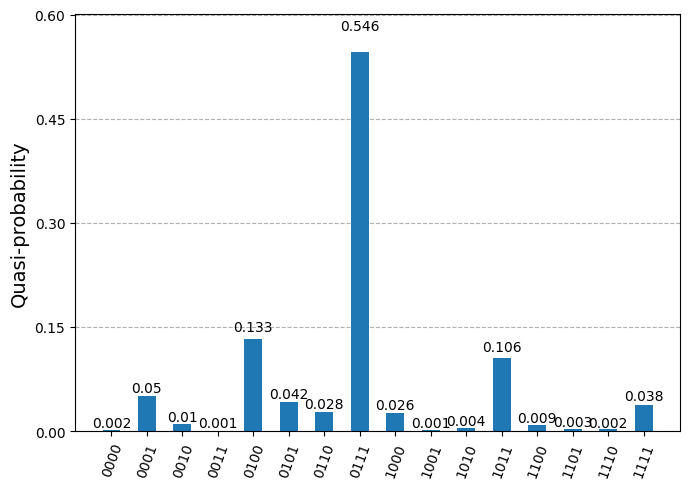

In [23]:
from qiskit.visualization import plot_distribution

plot_distribution(counts_bit)


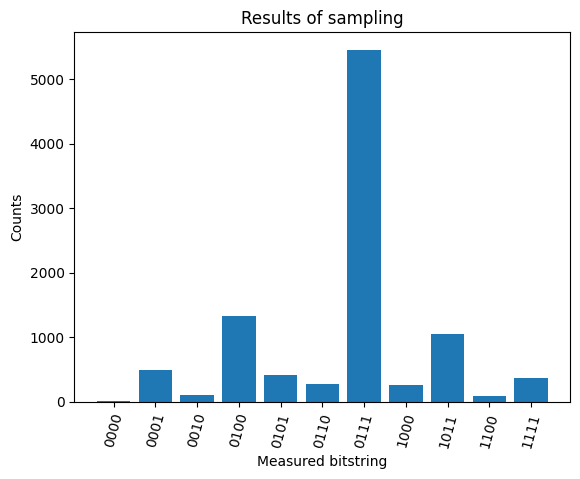

In [24]:
visualize_counts(counts, overlap_circ.num_qubits)

END of KERNEL VALIDATION METHODS

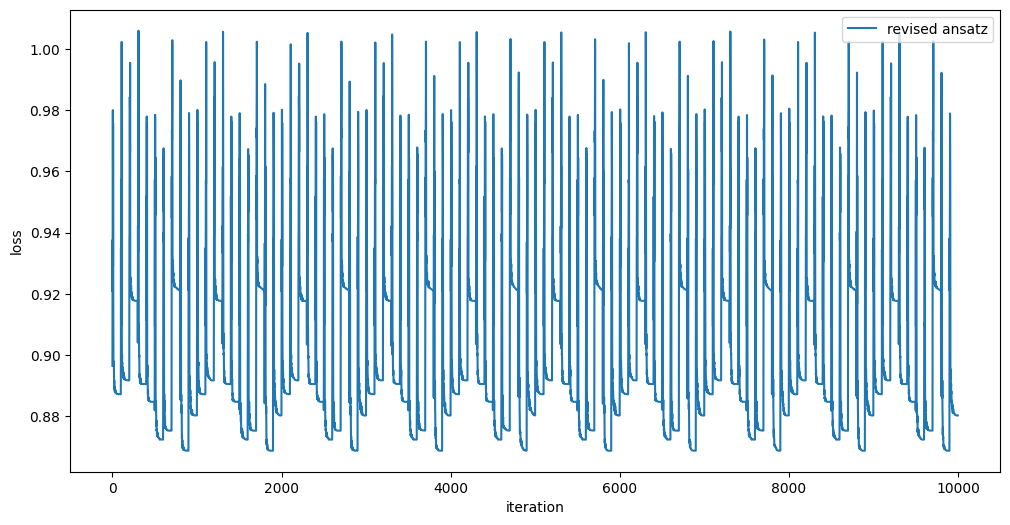

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals, label="revised ansatz")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.show()

In [44]:
import copy
from sklearn.metrics import accuracy_score
from qiskit.primitives import StatevectorEstimator as Estimator  # simulator
#from qiskit_ibm_runtime import EstimatorV2 as Estimator  # real quantum computer

#estimator = Estimator()
#estimator = Estimator(backend=backend)

# Saved weights from previous training
#weight_params = [7.93003622, 4.8410845,  6.48850167, 2.47624698, 6.7189891,  0.91598247, 3.72400573, 5.02482112]
#weight_params = np.full(len(ansatz.parameters), 0.5) * 2 * np.pi

#[ 72.06960616  81.95897549  50.12440516 106.18568048  32.02334152 31.1162085    7.71122007  11.90835599]

pred_test = forward(circuit, np.array(X_test), weight_params, estimator, observable)
accuracy = accuracy_score(test_labels, convert_prediction_to_label(pred_test))

print(f"Train accuracy: {accuracy * 100}%")

Train accuracy: 64.95%


In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score

# This method wil run a loop for different batch sizes to find the one that performs the best.
# Saves output to csv 
results = []
for i in range (1, 11):
    batch_size = i * 100
    weight_params = execute_training_with_estimator(batch_size=batch_size, epochs=1, samples=len(X_train), qc=full_circuit, weight_params=None)
    pred_test = forward(circuit, np.array(X_test), weight_params, estimator, observable)
    accuracy = accuracy_score(test_labels, convert_prediction_to_label(pred_test))
    results.append((batch_size, weight_params, accuracy))

print ("Results-------------------------")
for result in results:
    print(f"Batch Size: {result[0]}")
    print(f"Weights: {result[1]}")
    print(f"Accuracy: {result[2]}")
    print("-----")


result_df = pd.DataFrame(results)
# Save DataFrame to CSV without row indices
result_df.to_csv("results_raw_output.csv", index=False)

Epoch: 0, batch: 0
[2.35330497 5.97351416 4.59925358 3.76148219 0.98029403 0.98014248
 0.3649501  5.44234523]
Iter: 0, loss: 1.0796560107121929
Iter: 50, loss: 0.8697766373961798
Epoch: 0, batch: 1
[1.42693794 6.51129993 4.72585052 5.04688691 0.7382918  2.11069986
 0.2915747  6.89614793]
Iter: 0, loss: 1.0569911735758928
Iter: 50, loss: 0.8952514755725401
Epoch: 0, batch: 2
[2.62215719 7.437914   3.50185604 3.59562175 0.3109873  1.41288459
 0.03436473 5.66651215]
Iter: 0, loss: 1.0431479678112319
Iter: 50, loss: 0.8938197021943384
Epoch: 0, batch: 3
[3.7196144  6.51018839 3.44657795 2.54681687 0.75270789 1.03177928
 0.902067   5.34167407]
Iter: 0, loss: 0.9771131368827172
Iter: 50, loss: 0.8731300051483777
Epoch: 0, batch: 4
[4.52605309 6.78102937 4.55073297 2.00797702 0.81176671 1.13588782
 1.35001097 6.549645  ]
Iter: 0, loss: 0.8859790249005057
Iter: 50, loss: 0.8118834867447697
Epoch: 0, batch: 5
[4.66465796 6.72308151 4.67944498 2.86171886 0.53010511 0.86879937
 1.44141805 6.06096